# Loading data for sol-ai
Now we will load data also in a way to load multiple entries for the same sample.

## Authenticating
First we need to get an API token. Please use your nomad emali address from your account.  This token is used to access non public nomad entries. Since in this tutorial all entries are public we dont need it and keep the token empty. By providing your email you will get a token which you can use to access non public entries.

In [3]:
import requests
import getpass

url = "https://www.sol-ai.de/nomad-oasis/api/v1"
email = "michael.goette@helmholtz-berlin.de"

def get_token(url, name=None):
    user = name if name is not None else input("Username")
    print("Passwort: \n")
    password = getpass.getpass()
    # Get a token from the api, login
    response = requests.get(
        f'{url}/auth/token', params=dict(username=user, password=password))   
    return response.json()['access_token']

# get al entries related to this batch id
token = get_token(url,email) if email else ""
token

Passwort: 



 ········


'eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJmb1hmZnM5QlFQWHduLU54Yk5PYlExOFhnZnlKU1FNRkl6ZFVnWjhrZzdVIn0.eyJleHAiOjE3MjU2MjYyNzMsImlhdCI6MTcyNTUzOTg3MywianRpIjoiMTJkNzJmMTktNTlkNS00NjA3LThhOGUtZDEzZGI1ZmQ3MDBjIiwiaXNzIjoiaHR0cHM6Ly9ub21hZC1sYWIuZXUvZmFpcmRpL2tleWNsb2FrL2F1dGgvcmVhbG1zL2ZhaXJkaV9ub21hZF9wcm9kIiwic3ViIjoiZTI3OTY1OTQtNmE4NS00YTBiLWE3YWUtNTg2MjUwNWMyNGQ3IiwidHlwIjoiQmVhcmVyIiwiYXpwIjoibm9tYWRfcHVibGljIiwic2Vzc2lvbl9zdGF0ZSI6IjQ1Y2JkYzRmLWMwNTQtNDRiNS1hNGVmLWQ4MzYzZmI0MjI2NCIsInNjb3BlIjoib3BlbmlkIHByb2ZpbGUgZW1haWwiLCJzaWQiOiI0NWNiZGM0Zi1jMDU0LTQ0YjUtYTRlZi1kODM2M2ZiNDIyNjQiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwibmFtZSI6Ik1pY2hhZWwgR8O2dHRlIiwicHJlZmVycmVkX3VzZXJuYW1lIjoibWljaGFlbGdvZXR0ZSIsImdpdmVuX25hbWUiOiJNaWNoYWVsIiwiZmFtaWx5X25hbWUiOiJHw7Z0dGUiLCJlbWFpbCI6Im1pY2hhZWwuZ29ldHRlQGhlbG1ob2x0ei1iZXJsaW4uZGUifQ.Q0YAlaCcl37u65CmQf4J-nl4KKir6sMGiIdN1-gWPXbecvmpcgSHwjf5hux4qhlL6UJogJ5OdsayqfgN3_rAAvX60oUtcolAMbVf9MG7dP4peWBk0AkMBKyo1iVW0rlSORE3TXd_UNhXTjFwnbFPQQea4SyDyvcMpbYy

## Get all samples of specific type/group
We only need the entry_ids for now.

In [18]:
query = {
    'required': {
        "include":['entry_id']
    },
    'owner': 'visible',
    'query': {'entry_type': "peroTF_Sample"},
    'pagination': {
        'page_size': 10
    }
}
response = requests.post(f'{url}/entries/query',
                         headers={'Authorization': f'Bearer {token}'}, json=query)
entry_data = response.json()["data"]
entry_data[0]

{'entry_id': '-niVx5j3FJltBwCtNRNdKoUW8xf3'}

# Get all JV or PLI measurements linked to an entry
The parent classes of an entry are stored in `section_defs.definition_qualified_name` the following works for all jv measurements independen if they are from KIT HIERN or HZB HySprint since they use the same parent class. The quantity `entry_references.target_entry_id` contains all the linked entries. With the keyword `any` we match against all entries at once. Here we again use paging and plot one jv curve at the end.

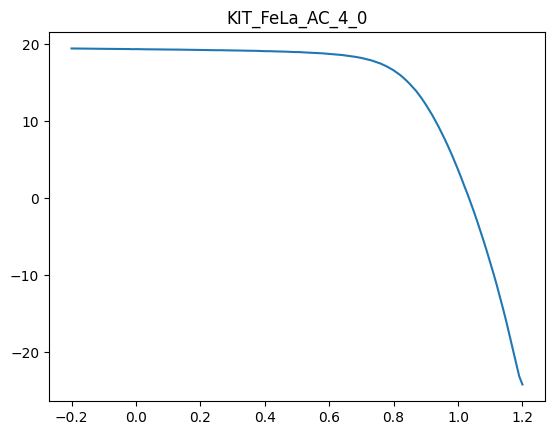

In [23]:
query = {
    'required': {
        "data":'*'
    },
    'owner': 'visible',
    'query': {'section_defs.definition_qualified_name': 'baseclasses.solar_energy.jvmeasurement.JVMeasurement',
             'entry_references.target_entry_id:any': [d["entry_id"] for d in entry_data]},
    'pagination': {
        'page_size': 10
    }
}
response = requests.post(f'{url}/entries/archive/query',
                         headers={'Authorization': f'Bearer {token}'}, json=query)
data = response.json()["data"]

import matplotlib.pyplot as plt
plt.figure()
plt.title(data[0]["archive"]["data"]["samples"][0]["lab_id"])
plt.plot(data[0]["archive"]["data"]["jv_curve"][0]["voltage"],data[0]["archive"]["data"]["jv_curve"][0]["current_density"])
plt.show()


PL Image

In [33]:
query = {
    'required': {
        "data":'*',
        "metadata":'*'
    },
    'owner': 'visible',
    'query': {'section_defs.definition_qualified_name': 'baseclasses.solar_energy.plimaging.PLImaging',
             'entry_references.target_entry_id:any': [d["entry_id"] for d in entry_data]},
    'pagination': {
        'page_size': 10
    }
}
response = requests.post(f'{url}/entries/archive/query',
                         headers={'Authorization': f'Bearer {token}'}, json=query)
data = response.json()["data"]

import matplotlib.pyplot as plt
data[0]["archive"]["data"]["data_file"] 


'ADS_14.hdf5'

Download the raw file and load it as hdf5 we install `h5py` for this.

In [38]:
%%capture
!pip install h5py

In [44]:
upload_id = data[0]["archive"]["metadata"]["upload_id"]
response = requests.get(f'{url}/uploads/{upload_id}/raw/{data[0]["archive"]["data"]["data_file"] }',
                         headers={'Authorization': f'Bearer {token}'})


In [51]:
import h5py
import io
f = io.BytesIO(response.content)
img = h5py.File(f, "r")
img["data"]

<HDF5 dataset "data": shape (719, 5, 65, 56), type "<u2">

# Other data
The same can be done for any other data linked to the sample, eg possible spin coating processes.

In [30]:
query = {
    'required': {
        "data":'*'
    },
    'owner': 'visible',
    'query': {'section_defs.definition_qualified_name': 'baseclasses.wet_chemical_deposition.blade_coating.BladeCoating',
             'entry_references.target_entry_id:any': [d["entry_id"] for d in entry_data]},
    'pagination': {
        'page_size': 10
    }
}
response = requests.post(f'{url}/entries/archive/query',
                         headers={'Authorization': f'Bearer {token}'}, json=query)
data = response.json()["data"]

import matplotlib.pyplot as plt
data[0]["archive"]["data"]["layer"]

[{'layer_type': 'Absorber Layer',
  'layer_material_name': 'Cs0.17FA0.83Pb(I0.91Br0.09)3 ',
  'layer_material': 'Cs17H415Pb100C83I273Br27N166'}]

[]